In [1]:
##### SI Figure 1: grid-scale production

from pathlib import Path
import geopandas as gpd
import rioxarray as rio
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as mcolors
from matplotlib.patches import Rectangle

In [2]:
##### Load data

# Get the current working directory
cd = Path.cwd().parent.parent

production = rio.open_rasterio(f"{cd}/Results/Raster_model/reprojected/total_production_tonnes_2020.tif")
country_boundaries = gpd.read_file(f"{cd}/Data/Clean/Geographies/country_geo.shp")

# Set file path to figure repo
fd = "/Users/carinamanitius/Library/CloudStorage/OneDrive-UniversityofVermont/Documents/OneDrive/Dissertation/Chapter 1/Figures/FINAL_FIGURES"

In [3]:
##### Data prep

# align rasters to production grid
target_crs = "+proj=eck4 +lon_0=0 +x_0=0 +y_0=0 +datum=WGS84 +units=m +no_defs"
production = production.rio.reproject(target_crs)

country_boundaries = country_boundaries.to_crs(production.rio.crs)

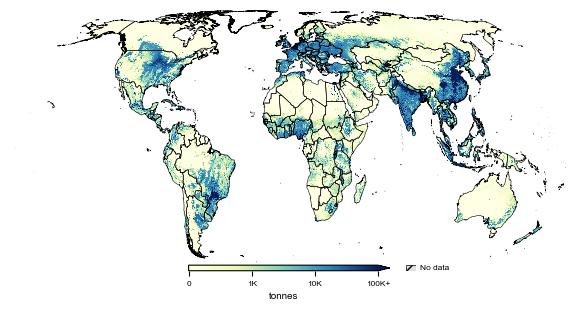

In [5]:
##### Global map of production

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial"],
})

# Prepare raster
value_plot = production.squeeze()

# set custom colormap
custom_cmap = mcolors.LinearSegmentedColormap.from_list(
    "white_ylgnbu",
    ["#ffffe5", "#edf8b1", "#7fcdbb", "#2c7fb8", "#081d58"]
)
custom_cmap.set_over("#081d58")  # color for the + triangle

# Set special equal-distant, manual scaling
bounds = [0, 1000, 10000, 100000]
labels = ['0', '1K', '10K', '100K+']

positions = np.linspace(0, 1, len(bounds))  # each bound gets an equal-width slice

def forward(x):
    return np.interp(x, bounds, positions)

def inverse(x):
    return np.interp(x, positions, bounds)

norm = mcolors.FuncNorm((forward, inverse), vmin=bounds[0], vmax=bounds[-1])

# Create figure — sized to double-column print width
fig, ax = plt.subplots(figsize=(7.2, 4.3))

# Country borders
country_boundaries.plot(
    ax=ax,
    facecolor="none",
    edgecolor="black",
    linewidth=0.4,
    zorder=2
)

# Raster
im = value_plot.plot(
    ax=ax,
    cmap=custom_cmap,
    norm=norm,
    add_colorbar=False,
    add_labels=False,
    zorder=1
)

ax.set_axis_off()
# Title removed — belongs in the caption, not on the figure itself

# Generate legend
cax = ax.inset_axes([0.32, 0.06, 0.36, 0.02], transform=ax.transAxes)

cbar = fig.colorbar(
    im,
    cax=cax,
    orientation="horizontal",
    extend='max',
    extendfrac=0.06,
)
cbar.set_label("tonnes", fontsize=7)
cbar.ax.tick_params(labelsize=6)

cbar.set_ticks(bounds)
cbar.set_ticklabels(labels)

# Add no data to legend
no_data_color = "#e0e0e0"
legend_ax = ax.inset_axes([0.71, 0.06, 0.018, 0.02], transform=ax.transAxes)
legend_ax.add_patch(Rectangle(
    (0, 0), 1, 1,
    facecolor=no_data_color,
    edgecolor="black",
    linewidth=0.5,
    hatch="///"
))
legend_ax.set_xlim(0, 1)
legend_ax.set_ylim(0, 1)
legend_ax.set_xticks([])
legend_ax.set_yticks([])
legend_ax.axis("off")

ax.text(
    0.735, 0.072, "No data",
    transform=ax.transAxes,
    fontsize=6, va="center", ha="left"
)

plt.show()

fig.savefig(f"{fd}/SI_figure_1_production.tiff", dpi=300, bbox_inches='tight')